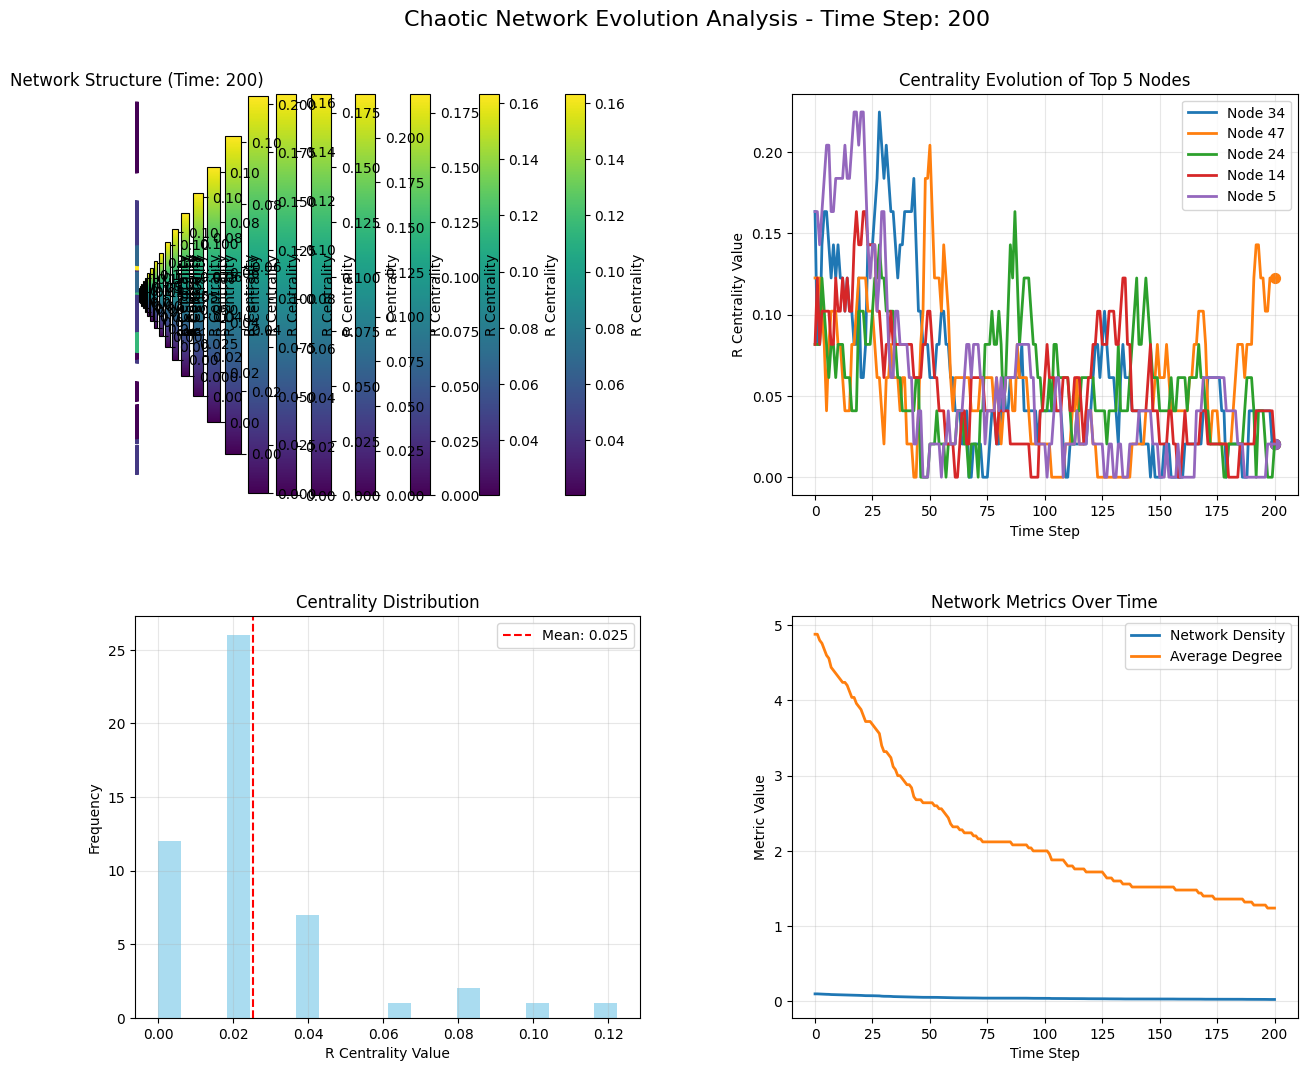

In [11]:
import matplotlib.animation as animation
from IPython.display import HTML
import seaborn as sns
import networkx as nx
import numpy as np
import matplotlib.pyplot as plt

def visualize_chaotic_evolution(evolving_networks, centrality_trajectories, sample_rate=10):
    """Create an animated visualization of network evolution under chaos"""
    fig, axes = plt.subplots(2, 2, figsize=(15, 12))
    plt.subplots_adjust(hspace=0.3, wspace=0.3)

    # Sample networks for animation
    sampled_networks = evolving_networks[::sample_rate]
    sampled_times = range(0, len(evolving_networks), sample_rate)

    def update(frame):
        for ax in axes.flat:
            ax.clear()

        G_current = sampled_networks[frame]
        current_time = sampled_times[frame]

        # 1. Network visualization with centrality coloring
        pos = nx.spring_layout(G_current, seed=42)
        node_colors = [centrality_trajectories[node]['R_value'][current_time]
                      for node in G_current.nodes()]

        nx.draw_networkx_nodes(G_current, pos, ax=axes[0,0],
                              node_color=node_colors,
                              node_size=200,
                              cmap='viridis')
        nx.draw_networkx_edges(G_current, pos, ax=axes[0,0],
                              alpha=0.6, edge_color='gray')
        axes[0,0].set_title(f'Network Structure (Time: {current_time})')
        axes[0,0].set_axis_off()

        # Add colorbar
        sm = plt.cm.ScalarMappable(cmap='viridis',
                                 norm=plt.Normalize(min(node_colors), max(node_colors)))
        sm.set_array([])
        plt.colorbar(sm, ax=axes[0,0], label='R Centrality')

        # 2. Centrality trajectory plot
        top_5_nodes = sorted(centrality_trajectories.keys(),
                           key=lambda x: np.mean(centrality_trajectories[x]['R_value']),
                           reverse=True)[:5]

        for node in top_5_nodes:
            times = centrality_trajectories[node]['time_points'][:current_time+1]
            values = centrality_trajectories[node]['R_value'][:current_time+1]
            axes[0,1].plot(times, values, label=f'Node {node}', linewidth=2)
            axes[0,1].scatter([current_time], [values[-1] if values else 0], s=50)

        axes[0,1].set_xlabel('Time Step')
        axes[0,1].set_ylabel('R Centrality Value')
        axes[0,1].set_title('Centrality Evolution of Top 5 Nodes')
        axes[0,1].legend()
        axes[0,1].grid(True, alpha=0.3)

        # 3. Centrality distribution histogram
        current_centralities = [centrality_trajectories[node]['R_value'][current_time]
                              for node in G_current.nodes()]
        axes[1,0].hist(current_centralities, bins=20, alpha=0.7, color='skyblue')
        axes[1,0].axvline(np.mean(current_centralities), color='red',
                         linestyle='--', label=f'Mean: {np.mean(current_centralities):.3f}')
        axes[1,0].set_xlabel('R Centrality Value')
        axes[1,0].set_ylabel('Frequency')
        axes[1,0].set_title('Centrality Distribution')
        axes[1,0].legend()
        axes[1,0].grid(True, alpha=0.3)

        # 4. Network metrics over time
        time_points = list(range(current_time + 1))
        densities = [nx.density(evolving_networks[t]) for t in time_points]
        avg_degrees = [np.mean([d for n, d in evolving_networks[t].degree()])
                      for t in time_points]

        axes[1,1].plot(time_points, densities, label='Network Density', linewidth=2)
        axes[1,1].plot(time_points, avg_degrees, label='Average Degree', linewidth=2)
        axes[1,1].set_xlabel('Time Step')
        axes[1,1].set_ylabel('Metric Value')
        axes[1,1].set_title('Network Metrics Over Time')
        axes[1,1].legend()
        axes[1,1].grid(True, alpha=0.3)

        fig.suptitle(f'Chaotic Network Evolution Analysis - Time Step: {current_time}',
                    fontsize=16, y=0.95)

    anim = animation.FuncAnimation(fig, update, frames=len(sampled_networks),
                                  interval=200, repeat=True)
    return HTML(anim.to_jshtml())

# Define G_edge (replace with your actual network data)
G_edge = nx.erdos_renyi_graph(50, 0.1) # Example: Erdos-Renyi graph with 50 nodes and p=0.1

# Define placeholder functions (replace with your actual functions)
def chaotic_rewiring_simulation(G, time_steps, chaos_strength):
    evolving_networks = [G.copy()]
    for _ in range(time_steps):
        # Implement your chaotic rewiring logic here
        # Example: Randomly remove and add edges
        G_new = evolving_networks[-1].copy()
        num_edges = len(G_new.edges())
        num_edges_to_remove = min(int(num_edges * chaos_strength), num_edges)

        if num_edges_to_remove > 0:
            # Convert edges to strings for np.random.choice
            edges_as_strings = [str(edge) for edge in G_new.edges()]
            selected_edge_strings = np.random.choice(edges_as_strings, size=num_edges_to_remove, replace=False)
            # Convert selected strings back to edge tuples
            edges_to_remove = [eval(edge_str) for edge_str in selected_edge_strings]

            G_new.remove_edges_from(edges_to_remove)

        nodes = list(G_new.nodes())
        num_edges_to_add = num_edges_to_remove # Add the same number of edges removed
        for _ in range(num_edges_to_add):
            # Ensure there are at least two nodes to form an edge
            if len(nodes) >= 2:
                u, v = np.random.choice(nodes, size=2, replace=False)
                G_new.add_edge(u, v)
            else:
                break # Cannot add edges if less than 2 nodes

        evolving_networks.append(G_new)
    return evolving_networks

def analyze_centrality_dynamics(evolving_networks):
    centrality_trajectories = {}
    for node in evolving_networks[0].nodes():
        centrality_trajectories[node] = {'time_points': [], 'R_value': []}

    for i, G in enumerate(evolving_networks):
        # Implement your centrality calculation here
        # Example: Use degree centrality as a placeholder for R centrality
        centrality = nx.degree_centrality(G)
        for node, value in centrality.items():
            centrality_trajectories[node]['time_points'].append(i)
            centrality_trajectories[node]['R_value'].append(value)
    return centrality_trajectories

# Generate and display the animation
evolving_networks = chaotic_rewiring_simulation(G_edge, time_steps=200, chaos_strength=0.15)
centrality_trajectories = analyze_centrality_dynamics(evolving_networks)
visualize_chaotic_evolution(evolving_networks, centrality_trajectories)

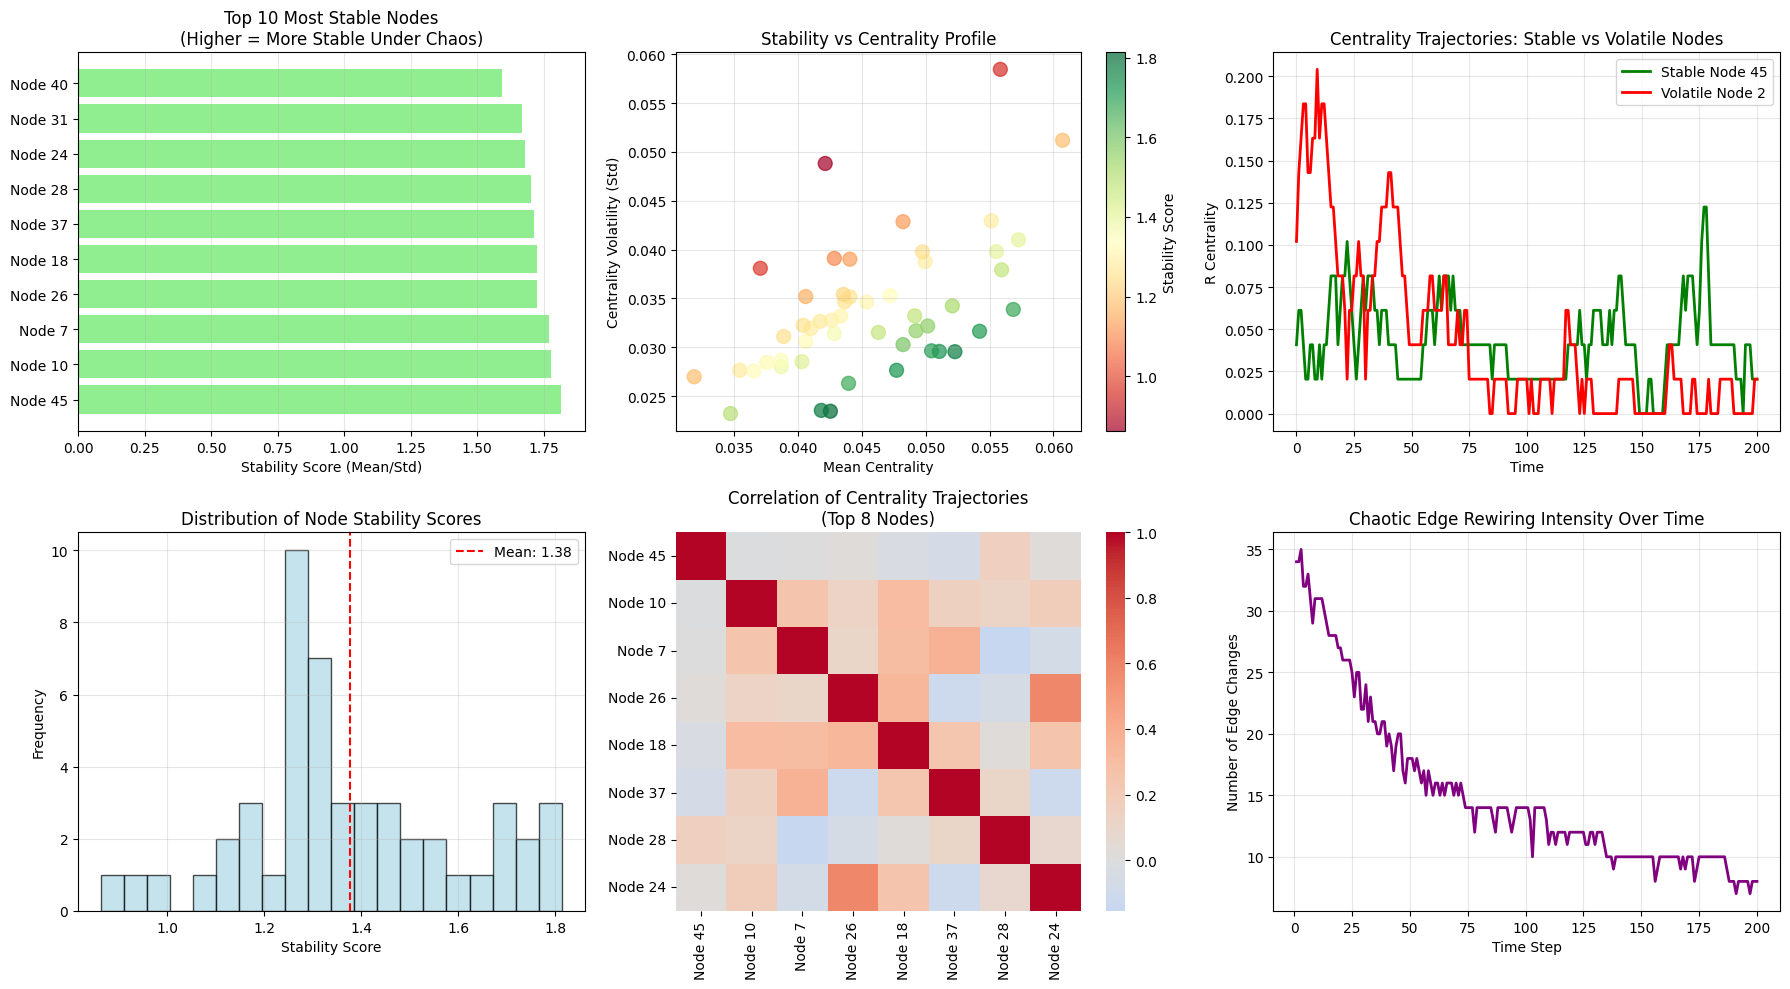

In [13]:
def plot_chaos_stability_analysis(centrality_trajectories, stability_scores):
    """Visualize the relationship between chaos and node stability"""
    fig, axes = plt.subplots(2, 3, figsize=(18, 10))

    # 1. Stability ranking
    top_stable = stability_scores[:10]
    nodes = [f"Node {item[0]}" for item in top_stable]
    stabilities_top10 = [item[1]['stability'] for item in top_stable]

    axes[0,0].barh(nodes, stabilities_top10, color='lightgreen')
    axes[0,0].set_xlabel('Stability Score (Mean/Std)')
    axes[0,0].set_title('Top 10 Most Stable Nodes\n(Higher = More Stable Under Chaos)')
    axes[0,0].grid(True, alpha=0.3, axis='x')

    # 2. Stability vs Mean Centrality scatter
    mean_centralities = [item[1]['mean_centrality'] for item in stability_scores]
    volatilities = [item[1]['volatility'] for item in stability_scores]
    stabilities_all = [item[1]['stability'] for item in stability_scores]
    node_ids = [item[0] for item in stability_scores]

    scatter = axes[0,1].scatter(mean_centralities, volatilities,
                               c=stabilities_all, cmap='RdYlGn', s=100, alpha=0.7)
    axes[0,1].set_xlabel('Mean Centrality')
    axes[0,1].set_ylabel('Centrality Volatility (Std)')
    axes[0,1].set_title('Stability vs Centrality Profile')
    plt.colorbar(scatter, ax=axes[0,1], label='Stability Score')
    axes[0,1].grid(True, alpha=0.3)

    # 3. Centrality trajectories comparison
    # Most stable vs most volatile nodes
    most_stable_node = stability_scores[0][0]
    most_volatile_node = min(stability_scores, key=lambda x: x[1]['stability'])[0]

    stable_traj = centrality_trajectories[most_stable_node]['R_value']
    volatile_traj = centrality_trajectories[most_volatile_node]['R_value']
    time_points = centrality_trajectories[most_stable_node]['time_points']

    axes[0,2].plot(time_points, stable_traj, label=f'Stable Node {most_stable_node}',
                  linewidth=2, color='green')
    axes[0,2].plot(time_points, volatile_traj, label=f'Volatile Node {most_volatile_node}',
                  linewidth=2, color='red')
    axes[0,2].set_xlabel('Time')
    axes[0,2].set_ylabel('R Centrality')
    axes[0,2].set_title('Centrality Trajectories: Stable vs Volatile Nodes')
    axes[0,2].legend()
    axes[0,2].grid(True, alpha=0.3)

    # 4. Distribution of stability scores
    all_stabilities = [item[1]['stability'] for item in stability_scores]
    axes[1,0].hist(all_stabilities, bins=20, alpha=0.7, color='lightblue', edgecolor='black')
    axes[1,0].axvline(np.mean(all_stabilities), color='red', linestyle='--',
                     label=f'Mean: {np.mean(all_stabilities):.2f}')
    axes[1,0].set_xlabel('Stability Score')
    axes[1,0].set_ylabel('Frequency')
    axes[1,0].set_title('Distribution of Node Stability Scores')
    axes[1,0].legend()
    axes[1,0].grid(True, alpha=0.3)

    # 5. Correlation heatmap of node centralities over time
    # Create a matrix of centrality values over time for top nodes
    top_nodes = [item[0] for item in stability_scores[:8]]
    centrality_matrix = np.array([centrality_trajectories[node]['R_value']
                                for node in top_nodes])

    correlation_matrix = np.corrcoef(centrality_matrix)
    sns.heatmap(correlation_matrix, ax=axes[1,1], cmap='coolwarm', center=0,
               xticklabels=[f'Node {n}' for n in top_nodes],
               yticklabels=[f'Node {n}' for n in top_nodes])
    axes[1,1].set_title('Correlation of Centrality Trajectories\n(Top 8 Nodes)')

    # 6. Chaos impact on network connectivity
    edge_changes = []
    for i in range(1, len(evolving_networks)):
        prev_edges = set(evolving_networks[i-1].edges())
        curr_edges = set(evolving_networks[i].edges())
        changes = len(prev_edges.symmetric_difference(curr_edges))
        edge_changes.append(changes)

    axes[1,2].plot(range(1, len(evolving_networks)), edge_changes,
                  color='purple', linewidth=2)
    axes[1,2].set_xlabel('Time Step')
    axes[1,2].set_ylabel('Number of Edge Changes')
    axes[1,2].set_title('Chaotic Edge Rewiring Intensity Over Time')
    axes[1,2].grid(True, alpha=0.3)

    plt.tight_layout()
    plt.show()

# Run analysis and plot
stability_scores = find_meta_central_nodes(centrality_trajectories)
plot_chaos_stability_analysis(centrality_trajectories, stability_scores)

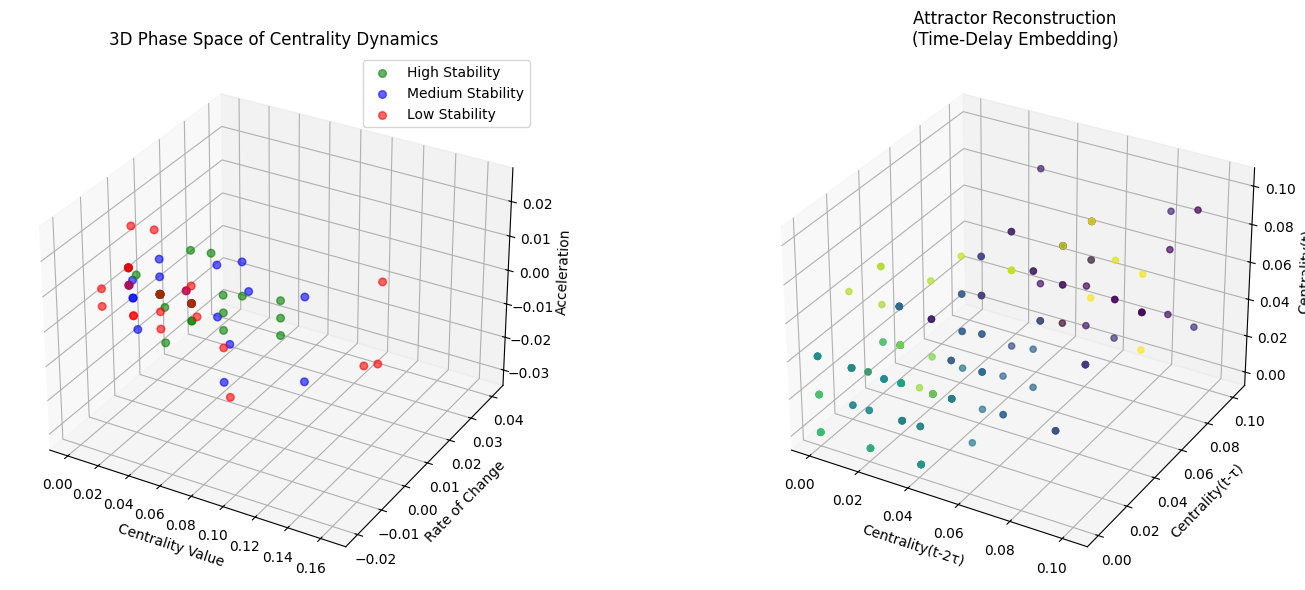

In [14]:
from mpl_toolkits.mplot3d import Axes3D

def plot_3d_centrality_phase_space(centrality_trajectories, stability_scores):
    """Create a 3D phase space visualization of centrality dynamics"""
    fig = plt.figure(figsize=(16, 6))

    # Plot 1: 3D Phase Space
    ax1 = fig.add_subplot(121, projection='3d')

    # Select representative nodes
    representative_nodes = [
        stability_scores[0][0],   # Most stable
        stability_scores[len(stability_scores)//2][0],  # Medium stability
        stability_scores[-1][0]   # Least stable
    ]

    colors = ['green', 'blue', 'red']
    labels = ['High Stability', 'Medium Stability', 'Low Stability']

    for i, node in enumerate(representative_nodes):
        traj = centrality_trajectories[node]
        # Use rolling statistics for smoothing
        centrality = traj['R_value']
        time_derivative = np.gradient(centrality)  # Rate of change
        acceleration = np.gradient(time_derivative)  # Second derivative

        # Plot every 10th point for clarity
        ax1.scatter(centrality[::10], time_derivative[::10], acceleration[::10],
                   c=colors[i], label=labels[i], alpha=0.6, s=30)

    ax1.set_xlabel('Centrality Value')
    ax1.set_ylabel('Rate of Change')
    ax1.set_zlabel('Acceleration')
    ax1.set_title('3D Phase Space of Centrality Dynamics')
    ax1.legend()

    # Plot 2: Attractor reconstruction
    ax2 = fig.add_subplot(122, projection='3d')

    # Use the most interesting node (medium stability)
    node = stability_scores[len(stability_scores)//2][0]
    centrality = centrality_trajectories[node]['R_value']

    # Create time-delay embedding for attractor reconstruction
    tau = 5  # time delay
    embedding = []
    for i in range(2*tau, len(centrality)):
        point = [centrality[i-2*tau], centrality[i-tau], centrality[i]]
        embedding.append(point)

    embedding = np.array(embedding)

    # Color by time
    colors = plt.cm.viridis(np.linspace(0, 1, len(embedding)))

    ax2.scatter(embedding[:, 0], embedding[:, 1], embedding[:, 2],
               c=colors, alpha=0.7, s=20)
    ax2.set_xlabel('Centrality(t-2τ)')
    ax2.set_ylabel('Centrality(t-τ)')
    ax2.set_zlabel('Centrality(t)')
    ax2.set_title('Attractor Reconstruction\n(Time-Delay Embedding)')

    plt.tight_layout()
    plt.show()

plot_3d_centrality_phase_space(centrality_trajectories, stability_scores)

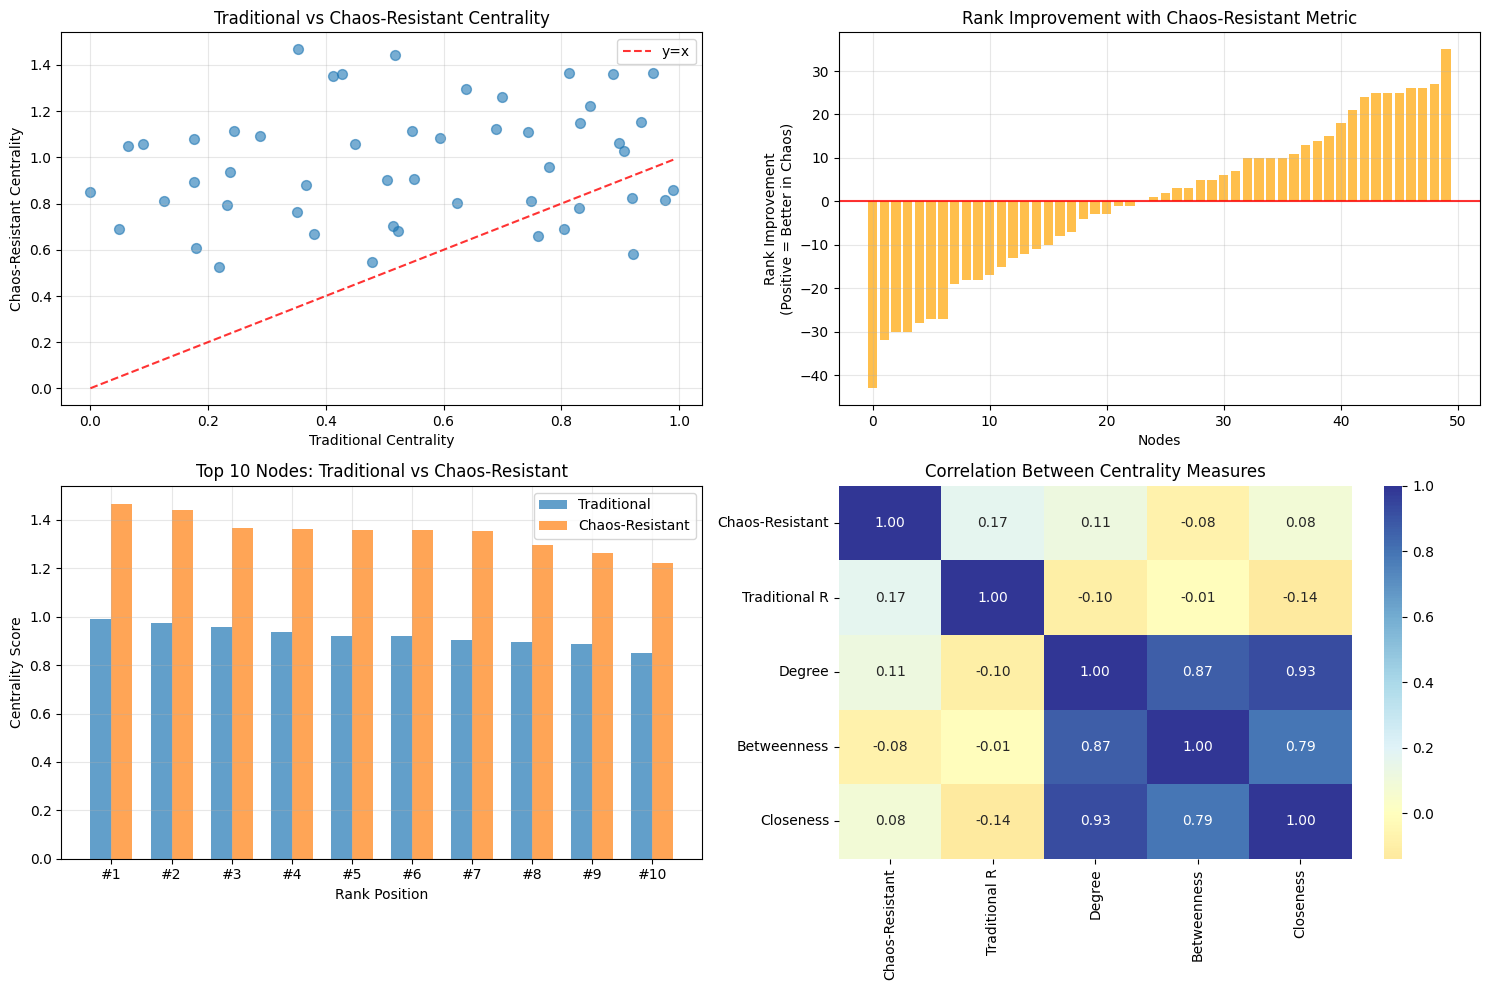

In [16]:
from mpl_toolkits.mplot3d import Axes3D

def compare_centrality_metrics(G, chaos_resistant_scores, traditional_scores):
    """Compare traditional vs chaos-resistant centrality metrics"""
    fig, axes = plt.subplots(2, 2, figsize=(15, 10))

    # Extract scores for comparison
    nodes = list(chaos_resistant_scores.keys())
    chaos_scores = [chaos_resistant_scores[node] for node in nodes]
    trad_scores = [traditional_scores[node] for node in nodes]

    # 1. Scatter plot comparison
    axes[0,0].scatter(trad_scores, chaos_scores, alpha=0.6, s=50)
    axes[0,0].plot([min(trad_scores), max(trad_scores)],
                  [min(trad_scores), max(trad_scores)],
                  'r--', alpha=0.8, label='y=x')
    axes[0,0].set_xlabel('Traditional Centrality')
    axes[0,0].set_ylabel('Chaos-Resistant Centrality')
    axes[0,0].set_title('Traditional vs Chaos-Resistant Centrality')
    axes[0,0].legend()
    axes[0,0].grid(True, alpha=0.3)

    # 2. Rank difference
    trad_ranks = {node: rank for rank, node in
                 enumerate(sorted(nodes, key=lambda x: trad_scores[nodes.index(x)], reverse=True))}
    chaos_ranks = {node: rank for rank, node in
                  enumerate(sorted(nodes, key=lambda x: chaos_scores[nodes.index(x)], reverse=True))}

    rank_differences = [trad_ranks[node] - chaos_ranks[node] for node in nodes]

    axes[0,1].bar(range(len(nodes)), sorted(rank_differences), color='orange', alpha=0.7)
    axes[0,1].axhline(y=0, color='red', linestyle='-', alpha=0.8)
    axes[0,1].set_xlabel('Nodes')
    axes[0,1].set_ylabel('Rank Improvement\n(Positive = Better in Chaos)')
    axes[0,1].set_title('Rank Improvement with Chaos-Resistant Metric')
    axes[0,1].grid(True, alpha=0.3)

    # 3. Top nodes comparison
    top_trad = sorted(nodes, key=lambda x: trad_scores[nodes.index(x)], reverse=True)[:10]
    top_chaos = sorted(nodes, key=lambda x: chaos_scores[nodes.index(x)], reverse=True)[:10]

    x_pos = np.arange(10)
    width = 0.35

    trad_values = [trad_scores[nodes.index(node)] for node in top_trad]
    chaos_values = [chaos_scores[nodes.index(node)] for node in top_chaos[:10]]

    axes[1,0].bar(x_pos - width/2, trad_values, width, label='Traditional', alpha=0.7)
    axes[1,0].bar(x_pos + width/2, chaos_values, width, label='Chaos-Resistant', alpha=0.7)
    axes[1,0].set_xlabel('Rank Position')
    axes[1,0].set_ylabel('Centrality Score')
    axes[1,0].set_title('Top 10 Nodes: Traditional vs Chaos-Resistant')
    axes[1,0].set_xticks(x_pos)
    axes[1,0].set_xticklabels([f'#{i+1}' for i in range(10)])
    axes[1,0].legend()
    axes[1,0].grid(True, alpha=0.3)

    # 4. Metric correlation heatmap
    # Calculate multiple centrality measures for comparison
    degree_centrality = nx.degree_centrality(G)
    betweenness_centrality = nx.betweenness_centrality(G)
    closeness_centrality = nx.closeness_centrality(G)

    measures = {
        'Chaos-Resistant': chaos_resistant_scores,
        'Traditional R': traditional_scores,
        'Degree': degree_centrality,
        'Betweenness': betweenness_centrality,
        'Closeness': closeness_centrality
    }

    # Create correlation matrix
    measure_names = list(measures.keys())
    correlation_matrix = np.zeros((len(measure_names), len(measure_names)))

    for i, measure1 in enumerate(measure_names):
        for j, measure2 in enumerate(measure_names):
            values1 = [measures[measure1][node] for node in nodes if node in measures[measure1]]
            values2 = [measures[measure2][node] for node in nodes if node in measures[measure2]]
            if len(values1) == len(values2) and len(values1) > 1:
                correlation_matrix[i, j] = np.corrcoef(values1, values2)[0, 1]

    sns.heatmap(correlation_matrix, ax=axes[1,1], cmap='RdYlBu', center=0,
               xticklabels=measure_names, yticklabels=measure_names,
               annot=True, fmt='.2f')
    axes[1,1].set_title('Correlation Between Centrality Measures')

    plt.tight_layout()
    plt.show()

# Define placeholder functions (replace with your actual functions)
def calculate_single_node_index(G):
    """Placeholder for calculating traditional centrality scores."""
    # Replace with your actual implementation
    traditional_scores = {node: np.random.rand() for node in G.nodes()}
    return traditional_scores, None # Return dummy scores and None for the second return value

def chaos_resistant_centrality(G):
    """Placeholder for calculating chaos-resistant centrality scores."""
    # Replace with your actual implementation
    chaos_resistant_scores = {node: np.random.rand() + 0.5 for node in G.nodes()} # Dummy scores
    return chaos_resistant_scores

# Calculate metrics and compare
traditional_scores, _ = calculate_single_node_index(G_edge)
chaos_resistant_scores = chaos_resistant_centrality(G_edge)
compare_centrality_metrics(G_edge, chaos_resistant_scores, traditional_scores)